# 03. 회귀 모델 시도 (Regression Trials)

폐업_률을 **연속값으로 직접 예측**하는 회귀 접근을 네 가지 모델로 시도한 기록이다.
각 모델은 전처리·타깃 정의·분할 방식이 조금씩 다르므로 **섹션별로 독립 실행**된다.
(각 섹션 맨 앞에서 `../data/eda/merged_data.csv`를 새로 로드한다.)

| 모델 | 타깃 | 인코딩 | 분할 | 비고 |
|------|------|--------|------|------|
| RandomForest | 당분기 폐업_률 | 숫자형 상위 상관 피처 | random 80/20 | 피처중요도·잔차분석 |
| CatBoost | 당분기 폐업_률 | OneHot | random | KFold·GridSearch |
| XGBoost | 당분기 폐업_률 | LabelEncoding | random 80/20 | 파생변수·GridSearch |
| LightGBM | 다음분기 폐업_률(shift) | category | 시계열 분할 | 누수 방지 |

> 결론: 회귀로는 R²가 낮아 실무적 예측력이 부족했고, 이후 **분류(상위 폐업률 구간)** 접근으로 전환했다.

## 0. 공통 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib
font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/eda/merged_data.csv'

## 1. RandomForest Regressor

숫자형 변수 중 폐업률과 상관이 높은 상위 7개 피처만 사용한다.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(DATA_PATH)

num_df = df.select_dtypes(include=['int64', 'float64'])
num_df = num_df.drop('폐업_점포_수', axis=1, errors='ignore')

C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\3451012374.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target[1:8], y=corr_target[1:8].index, palette='viridis')


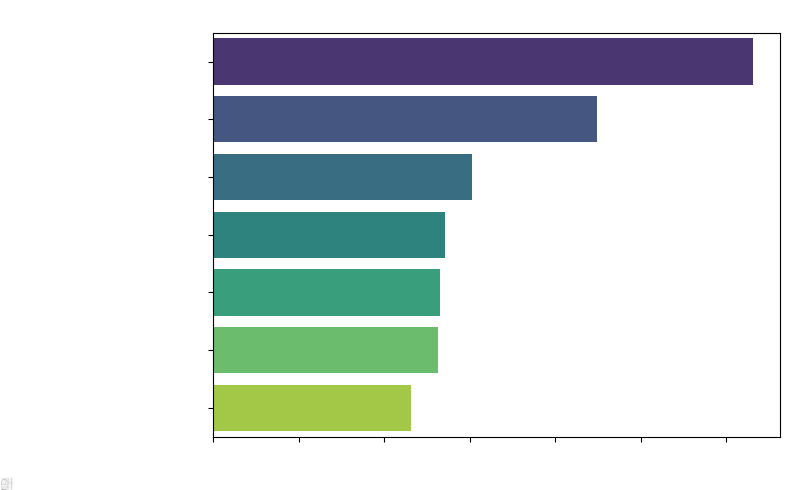

In [3]:
# 폐업률과의 상관관계 상위 변수
corr = num_df.corr()
target_col = '폐업_률'
corr_target = corr[target_col].sort_values(ascending=False)
important_features = corr_target[1:8].index.tolist()  # 상위 7개

plt.figure(figsize=(8, 5))
sns.barplot(x=corr_target[1:8], y=corr_target[1:8].index, palette='viridis')
plt.title('폐업률과의 상관관계 상위 변수')
plt.xlabel('상관계수'); plt.ylabel('변수명')
plt.tight_layout(); plt.show()

In [4]:
X = num_df[important_features]
y = num_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=600, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [5]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R2   : {r2:.4f}')

MAE  : 1.2262
MSE  : 3.2125
RMSE : 1.7923
R2   : 0.2262


C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1983681502.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=important_features, palette='coolwarm')


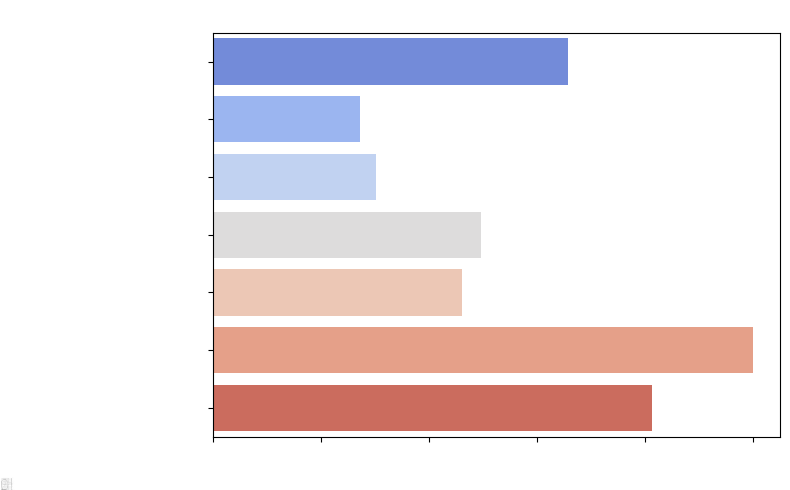

In [6]:
importances = rf.feature_importances_
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=important_features, palette='coolwarm')
plt.title('RandomForest 피처 중요도')
plt.xlabel('중요도'); plt.ylabel('피처명')
plt.tight_layout(); plt.show()

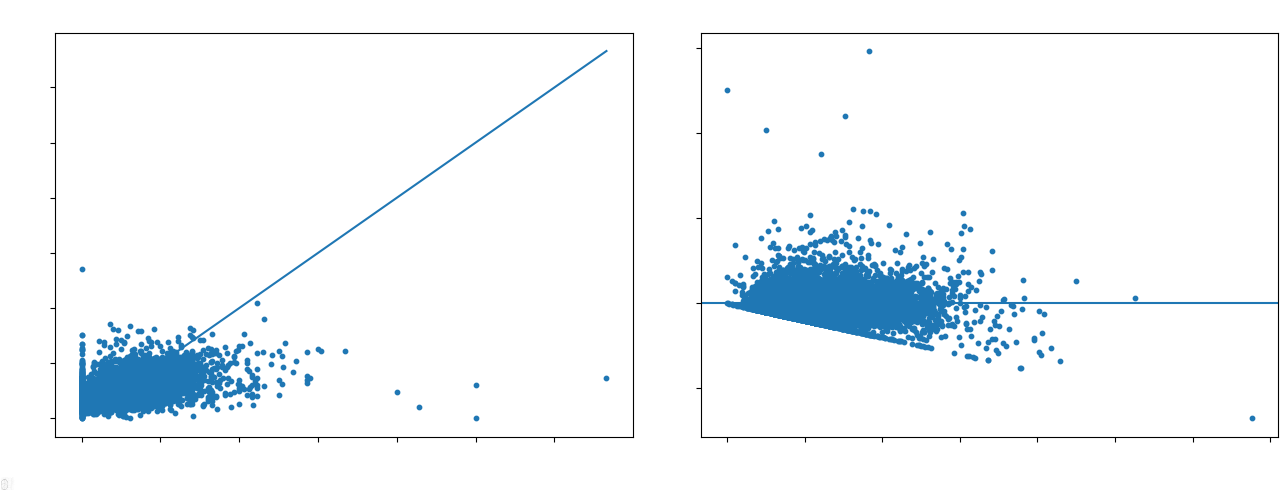

In [7]:
# 실제값 vs 예측값, 잔차 분석
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred, s=10)
vmin = float(np.nanmin([y_test.min(), y_pred.min()]))
vmax = float(np.nanmax([y_test.max(), y_pred.max()]))
axes[0].plot([vmin, vmax], [vmin, vmax])
axes[0].set_xlabel('실제값'); axes[0].set_ylabel('예측값'); axes[0].set_title('실제값 vs 예측값')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, s=10)
axes[1].axhline(0)
axes[1].set_xlabel('예측값'); axes[1].set_ylabel('잔차'); axes[1].set_title('잔차 분석')
plt.tight_layout(); plt.show()

## 2. CatBoost Regressor

범주형 변수를 OneHot 인코딩 후 CatBoostRegressor로 학습한다.

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv(DATA_PATH)
df = df.drop('폐업_점포_수', axis=1)

X = df.drop('폐업_률', axis=1)
y = df['폐업_률']

In [9]:
# 범주형 OneHot 인코딩
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = [c for c in X.columns if c not in categorical_cols]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=X.index)

X_encoded = pd.concat([X[numerical_cols], encoded_df], axis=1)

C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1902766975.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [10]:
X_train, X_valid, y_train, y_valid = train_test_split(X_encoded, y, random_state=42)

model = CatBoostRegressor(
    iterations=1000, learning_rate=0.1, depth=6,
    eval_metric='RMSE', early_stopping_rounds=50,
    verbose=100, use_best_model=True
)
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

y_pred = model.predict(X_valid)
print(f'RMSE: {np.sqrt(mean_squared_error(y_valid, y_pred)):.4f}')
print(f'MAE : {mean_absolute_error(y_valid, y_pred):.4f}')
print(f'R2  : {r2_score(y_valid, y_pred):.4f}')

0:	learn: 1.9515385	test: 1.9922497	best: 1.9922497 (0)	total: 208ms	remaining: 3m 27s


100:	learn: 1.5586789	test: 1.6819975	best: 1.6816702 (97)	total: 2.23s	remaining: 19.9s


200:	learn: 1.4745276	test: 1.6548281	best: 1.6546538 (198)	total: 4.31s	remaining: 17.1s


300:	learn: 1.4091890	test: 1.6464383	best: 1.6459118 (292)	total: 7.73s	remaining: 18s


400:	learn: 1.3575799	test: 1.6412669	best: 1.6408797 (385)	total: 10.7s	remaining: 16s


500:	learn: 1.3153006	test: 1.6410659	best: 1.6392784 (458)	total: 13.5s	remaining: 13.4s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.639278409
bestIteration = 458

Shrink model to first 459 iterations.
RMSE: 1.6393
MAE : 1.1125
R2  : 0.3483


C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\2551587930.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df.head(20), x='Importance', y='Feature', palette='viridis')


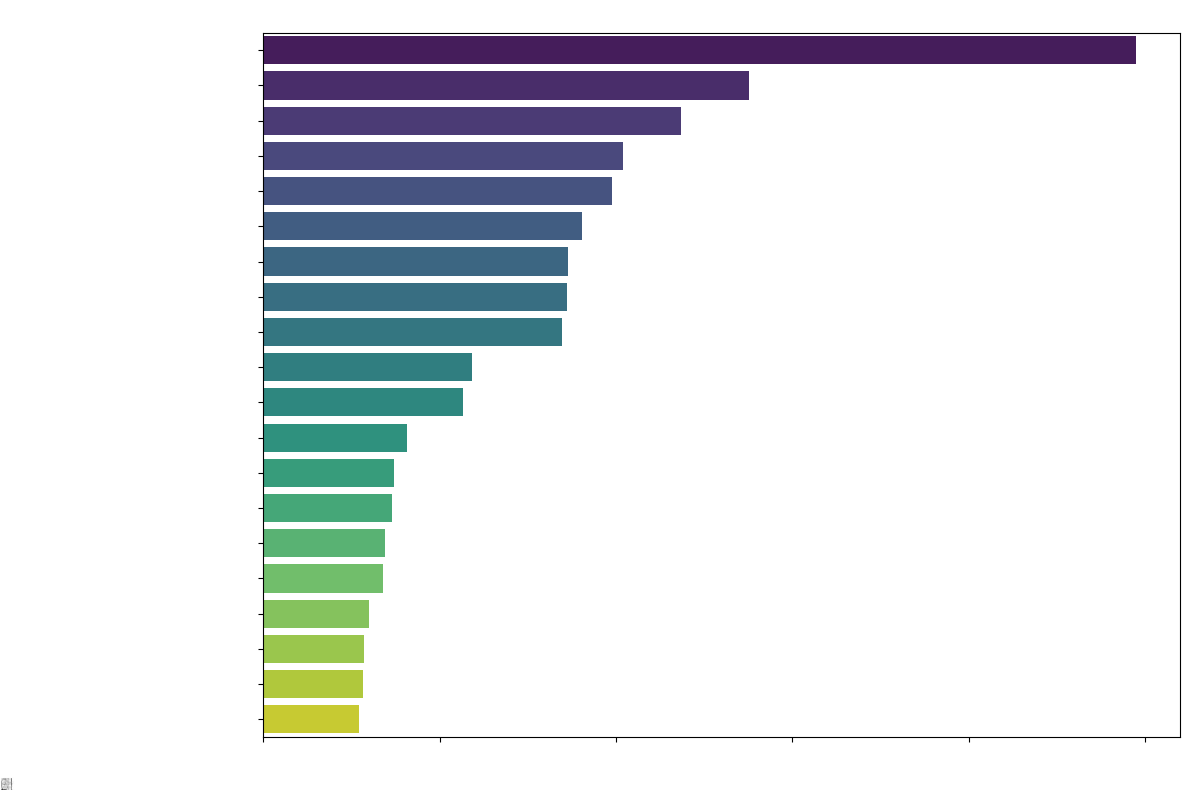

In [11]:
# 특성 중요도 (Top 20)
importances_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importances_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('CatBoost 특성 중요도 (Top 20)')
plt.tight_layout(); plt.show()

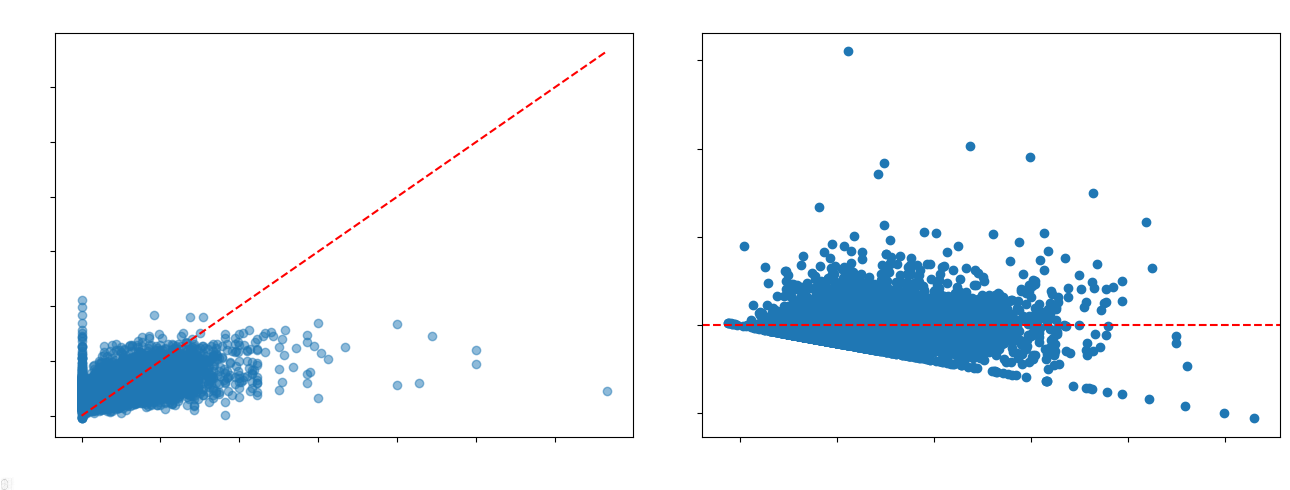

In [12]:
# 실제 vs 예측, 잔차
residuals = y_valid - y_pred
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_valid, y_pred, alpha=0.5)
axes[0].plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
axes[0].set_xlabel('실제 폐업률'); axes[0].set_ylabel('예측 폐업률'); axes[0].set_title('실제 vs 예측')
axes[1].scatter(y_pred, residuals)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('예측값'); axes[1].set_ylabel('잔차'); axes[1].set_title('잔차 분석')
plt.tight_layout(); plt.show()

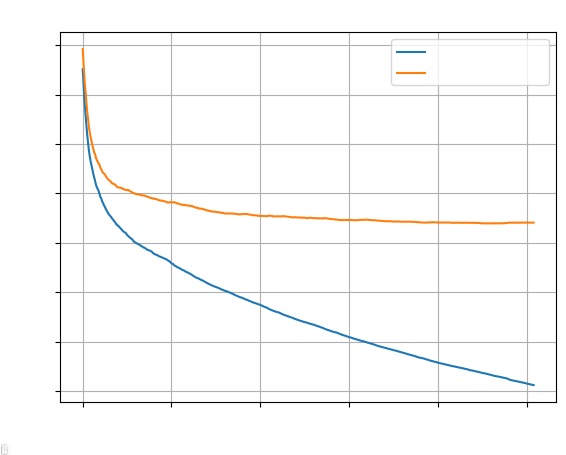

In [13]:
# 학습 곡선
evals_result = model.get_evals_result()
plt.plot(evals_result['learn']['RMSE'], label='Train RMSE')
plt.plot(evals_result['validation']['RMSE'], label='Validation RMSE')
plt.xlabel('Iteration'); plt.ylabel('RMSE')
plt.title('Training vs Validation RMSE')
plt.legend(); plt.grid(True); plt.show()

### KFold 교차검증

각 fold에서 자체 검증셋으로 평가하고 fold별 RMSE의 평균을 리포트한다.

In [14]:
# KFold (fold별 자체 검증셋으로 평가 → 평균)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmse, fold_mae, fold_r2 = [], [], []
for train_index, val_index in kf.split(X_encoded):
    X_tr_f, X_val_f = X_encoded.iloc[train_index], X_encoded.iloc[val_index]
    y_tr_f, y_val_f = y.iloc[train_index], y.iloc[val_index]

    fold_model = CatBoostRegressor(
        iterations=1000, learning_rate=0.1,
        eval_metric='RMSE', early_stopping_rounds=50, verbose=False
    )
    fold_model.fit(X_tr_f, y_tr_f, eval_set=(X_val_f, y_val_f))
    preds = fold_model.predict(X_val_f)

    fold_rmse.append(np.sqrt(mean_squared_error(y_val_f, preds)))
    fold_mae.append(mean_absolute_error(y_val_f, preds))
    fold_r2.append(r2_score(y_val_f, preds))

print(f'KFold RMSE: {np.mean(fold_rmse):.4f} (+/- {np.std(fold_rmse):.4f})')
print(f'KFold MAE : {np.mean(fold_mae):.4f}')
print(f'KFold R2  : {np.mean(fold_r2):.4f}')

KFold RMSE: 1.6048 (+/- 0.0282)
KFold MAE : 1.0975
KFold R2  : 0.3568


### GridSearchCV

탐색 공간을 가볍게 좁혀 best 파라미터를 확인한다.

In [15]:
from sklearn.model_selection import GridSearchCV

# 탐색 공간을 가볍게 축소 (원본의 광범위 탐색은 수십 분 소요)
params = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [500]
}

grid = GridSearchCV(
    estimator=CatBoostRegressor(verbose=0),
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=3
)
grid.fit(X_train, y_train)

print('최적의 파라미터:', grid.best_params_)
print('최적화된 점수(neg RMSE):', grid.best_score_)

최적의 파라미터: {'depth': 6, 'iterations': 500, 'learning_rate': 0.1}
최적화된 점수(neg RMSE): -1.6214026147831124


## 3. XGBoost Regressor

Label 인코딩 + 이상치(폐업률≥25) 제거 후 학습하고, 파생변수를 추가해 성능 개선을 시도한다.

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv(DATA_PATH)
df = df.drop(df[df['폐업_률'] >= 25].index)
df = df.drop(['폐업_점포_수', '폐업_영업_개월_평균', '서울시_폐업_영업_개월_평균'], axis=1)

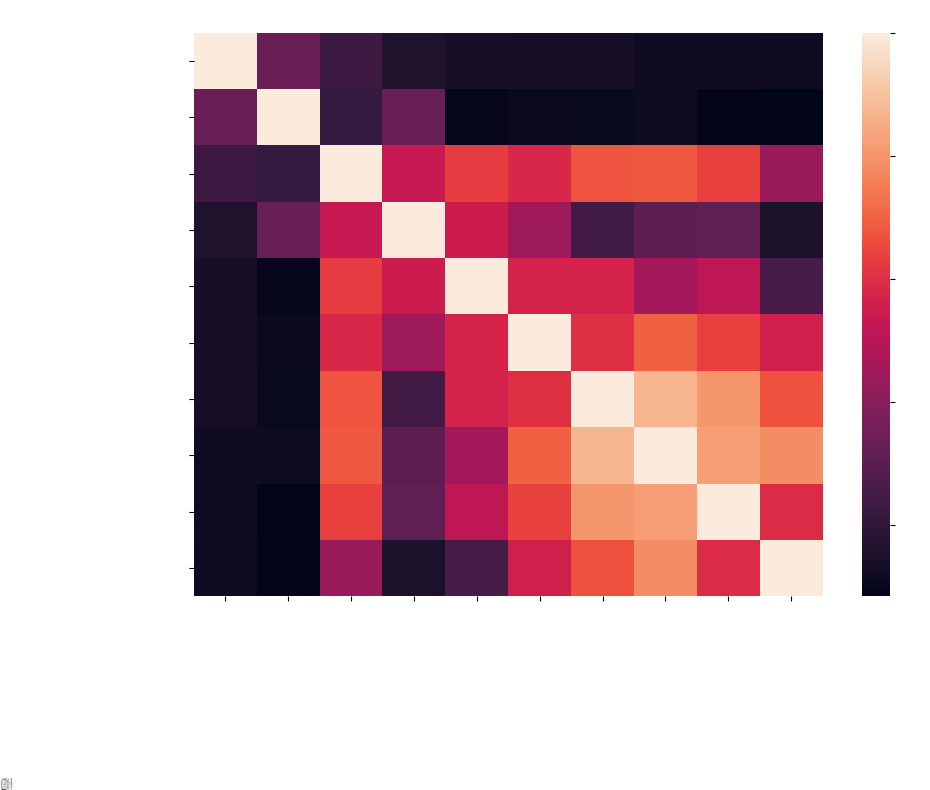

In [17]:
# 폐업률 상관 상위 변수 히트맵
corr = df.corr(numeric_only=True)
target_corr = corr['폐업_률'].dropna()
top_features = target_corr.abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10, 8))
sns.heatmap(corr.loc[top_features, top_features], annot=True, fmt='.2f')
plt.title('폐업률 상관 상위 변수')
plt.tight_layout(); plt.show()

In [18]:
# 레이블 인코딩
cols = ['자치구_코드_명', '서비스_업종_코드_명', '상권_변화_지표']
for col in cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [19]:
# 기본 모델 학습
X = df.drop('폐업_률', axis=1)
y = df['폐업_률']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_test)

print('[기본 피처]')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R2  : {r2_score(y_test, y_pred):.4f}')

[기본 피처]
RMSE: 1.5546
MAE : 1.0922
R2  : 0.3606


### 성능 개선: 파생변수 추가

In [20]:
# 매출 구조·인구 비율 등 파생변수
df['건당_매출액'] = df['당월_매출_금액'] / (df['당월_매출_건수'] + 1e-6)
df['주중_매출_금액'] = df['월요일_매출_금액'] + df['화요일_매출_금액'] + df['수요일_매출_금액'] + df['목요일_매출_금액'] + df['금요일_매출_금액']
df['주말_매출_금액'] = df['토요일_매출_금액'] + df['일요일_매출_금액']
df['주중_매출_비율'] = df['주중_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
df['주말_매출_비율'] = df['주말_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
df['저녁시간_매출_비율'] = df['시간대_17_21_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
df['여성_매출_비율'] = df['여성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
df['남성_매출_비율'] = df['남성_매출_금액'] / (df['당월_매출_금액'] + 1e-6)
df['유동인구_대비_상주인구_비율'] = df['총_상주인구_수'] / (df['총_유동인구_수'] + 1e-6)

df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
df['분기'] = df['기준_년분기_코드'].astype(str).str[4:].astype(int)

C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1239174116.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['건당_매출액'] = df['당월_매출_금액'] / (df['당월_매출_건수'] + 1e-6)
C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1239174116.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['주중_매출_금액'] = df['월요일_매출_금액'] + df['화요일_매출_금액'] + df['수요일_매출_금액'] + df['목요일_매출_금액'] + df['금요일_매출_금액']
C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1239174116.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result 

C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1239174116.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\1239174116.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['분기'] = df['기준_년분기_코드'].astype(str).str[4:].astype(int)


In [21]:
# 전년 동기 대비 증감 (shift 4분기)
df = df.sort_values(by=['자치구_코드_명', '서비스_업종_코드_명', '연도', '분기'])
df['전년_당월_매출액'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['당월_매출_금액'].shift(4)
df['전년_유사_업종_점포_수'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['유사_업종_점포_수'].shift(4)
df['당월매출증감'] = df['당월_매출_금액'] - df['전년_당월_매출액']
df['유사업종점포수증감'] = df['유사_업종_점포_수'] - df['전년_유사_업종_점포_수']

# 첫 해 결측은 평균 대체
for c in ['당월매출증감', '유사업종점포수증감', '전년_당월_매출액', '전년_유사_업종_점포_수']:
    df[c] = df[c].fillna(df[c].mean())

C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\3969806661.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['전년_당월_매출액'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['당월_매출_금액'].shift(4)
C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\3969806661.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['전년_유사_업종_점포_수'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['유사_업종_점포_수'].shift(4)
C:\Users\kouls\AppData\Local\Temp\ipykernel_20892\3969806661.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the resu

In [22]:
# 다중공선성 높은 세부 인구/지출/유동 컬럼 정리
drop_cols = [
    '남성_유동인구_수', '여성_유동인구_수',
    '연령대_10_직장인구_수', '연령대_20_직장인구_수', '연령대_30_직장인구_수',
    '연령대_40_직장인구_수', '연령대_50_직장인구_수', '연령대_60_이상_직장인구_수',
    '남성연령대_10_직장_인구_수', '남성연령대_20_직장_인구_수', '남성연령대_30_직장_인구_수',
    '남성연령대_40_직장_인구_수', '남성연령대_50_직장_인구_수', '남성연령대_60_이상_직장_인구_수',
    '여성연령대_10_직장_인구_수', '여성연령대_20_직장_인구_수', '여성연령대_30_직장_인구_수',
    '여성연령대_40_직장_인구_수', '여성연령대_50_직장_인구_수', '여성연령대_60_이상_직장_인구_수',
    '남성_상주인구_수', '여성_상주인구_수',
    '연령대_10_미만_상주인구_수', '연령대_20_상주인구_수', '연령대_30_상주인구_수',
    '연령대_40_상주인구_수', '연령대_50_상주인구_수', '연령대_60_이상_상주인구_수',
    '남성연령대_10_상주인구_수', '남성연령대_20_상주인구_수', '남성연령대_30_상주인구_수',
    '남성연령대_40_상주인구_수', '남성연령대_50_상주인구_수', '남성연령대_60_이상_상주인구_수',
    '여성연령대_10_상주인구_수', '여성연령대_20_상주인구_수', '여성연령대_30_상주인구_수',
    '여성연령대_40_상주인구_수', '여성연령대_50_상주인구_수', '여성연령대_60_이상_상주인구_수',
    '식료품_지출_총금액', '의류_신발_지출_총금액', '생활용품_지출_총금액', '교통_지출_총금액',
    '교육_지출_총금액', '유흥_지출_총금액', '여가_문화_지출_총금액',
    '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
    '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
    '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수',
    '금요일_유동인구_수', '토요일_유동인구_수', '일요일_유동인구_수',
]
df = df.drop(drop_cols, axis=1)

In [23]:
# 개선 피처로 재학습
X = df.drop('폐업_률', axis=1)
y = df['폐업_률']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_reg = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.7, random_state=42
)
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_test)

print('[개선 피처]')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R2  : {r2_score(y_test, y_pred):.4f}')

[개선 피처]
RMSE: 1.4773
MAE : 1.0450
R2  : 0.4361


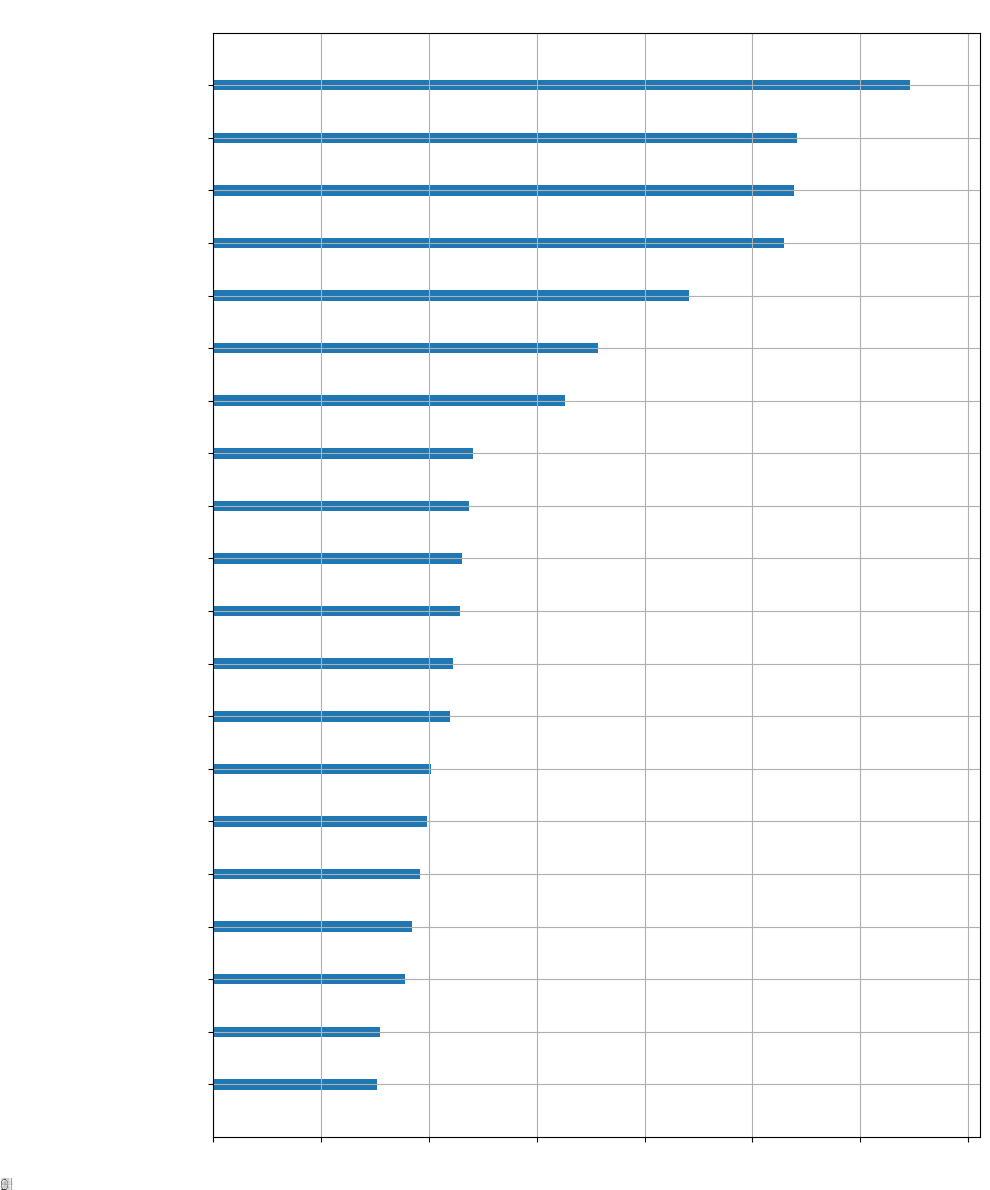

In [24]:
fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_reg, ax=ax, max_num_features=20)
plt.title('XGBoost 피처 중요도 (Top 20)')
plt.tight_layout(); plt.show()

### GridSearchCV

탐색 공간을 가볍게 좁혀 best 파라미터를 확인한다.

In [25]:
from sklearn.model_selection import GridSearchCV

# 탐색 공간 축소 (원본의 243개 조합 x cv3 은 매우 오래 걸림)
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8],
}
grid_search = GridSearchCV(
    estimator=XGBRegressor(subsample=0.9, colsample_bytree=0.7, random_state=42),
    param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
best_model = grid_search.best_estimator_
print(f'R2-score: {r2_score(y_test, best_model.predict(X_test)):.4f}')

Best parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
R2-score: 0.4361


## 4. LightGBM Regressor (시계열)

현재 분기 피처로 **다음 분기 폐업률**을 예측한다 (그룹별 shift). 분할도 최신 분기를 테스트, 그 직전 분기를 검증으로 두는 시계열 방식이라 데이터 누수를 방지한다.

In [26]:
import lightgbm as lgb
from pandas.api.types import CategoricalDtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)

must_have = ['기준_년분기_코드', '자치구_코드_명', '서비스_업종_코드_명', '폐업_률']
missing = [c for c in must_have if c not in df.columns]
if missing:
    raise ValueError(f'다음 컬럼이 필요합니다: {missing}')

(39975, 137)


In [27]:
# 타깃: t 시점 피처로 t+1 분기 폐업_률 예측
df = df.sort_values(['자치구_코드_명', '서비스_업종_코드_명', '기준_년분기_코드']).copy()
df['y'] = df.groupby(['자치구_코드_명', '서비스_업종_코드_명'])['폐업_률'].shift(-1)
df = df.dropna(subset=['y']).reset_index(drop=True)
print('[INFO] After creating y (next-quarter 폐업_률):', df.shape)

[INFO] After creating y (next-quarter 폐업_률):

 (38419, 138)


In [28]:
# 피처 구성: 상권_변화_지표는 순서형 + 수치 파생
cat_cols = ['자치구_코드_명', '서비스_업종_코드_명']
biz_order = ['LL', 'LH', 'HL', 'HH']
biz_dtype = CategoricalDtype(categories=biz_order, ordered=True)

if '상권_변화_지표' in df.columns:
    col = '상권_변화_지표'
    df[col] = df[col].astype('string').str.strip()
    df.loc[~df[col].isin(biz_order), col] = pd.NA
    df[col] = df[col].astype(biz_dtype)
    score_map = {'LL': 0, 'LH': 1, 'HL': 2, 'HH': 3}
    df[col + '_순위'] = df[col].map(score_map).astype('float').fillna(-1.0)
    cat_cols.append(col)

for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

obj_cols = df.select_dtypes(include='object').columns
if len(obj_cols) > 0:
    df[obj_cols] = df[obj_cols].astype('category')

X = df.drop(columns=['y']).copy()
y = df['y'].copy()
cat_in_X = [c for c in cat_cols if c in X.columns]
print('[CHECK] object columns in X:', X.select_dtypes(include='object').columns.tolist())

[CHECK] object columns in X: []


In [29]:
# 시계열 분할: 최신 분기=테스트, 직전=검증, 나머지=학습
quarters = np.sort(df['기준_년분기_코드'].unique())
test_q = quarters[-1]
val_q  = quarters[-2]

tr_mask  = X['기준_년분기_코드'] <  val_q
val_mask = X['기준_년분기_코드'] == val_q
te_mask  = X['기준_년분기_코드'] == test_q

X_tr,  y_tr  = X[tr_mask],  y[tr_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[te_mask], y[te_mask]

print(f'[INFO] Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'[INFO] Test quarter = {int(test_q)} / Val quarter = {int(val_q)}')

[INFO] Train: (35359, 138), Val: (1531, 138), Test: (1529, 138)
[INFO] Test quarter = 20251 / Val quarter = 20244


In [30]:
model = lgb.LGBMRegressor(
    objective='regression', learning_rate=0.08, num_leaves=63,
    n_estimators=3000, feature_fraction=0.9, bagging_fraction=0.9,
    bagging_freq=1, min_child_samples=50, reg_lambda=3.0,
    random_state=42, verbosity=-1
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='l2',
    categorical_feature=cat_in_X,
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

C:\project\portfolio\Seoul-Store-Closure-Prediction\project_env\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LGBMRegressor(bagging_fraction=0.9, bagging_freq=1, feature_fraction=0.9,
              learning_rate=0.08, min_child_samples=50, n_estimators=3000,
              num_leaves=63, objective='regression', random_state=42,
              reg_lambda=3.0, verbosity=-1)

In [ ]:
pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, pred)
mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, pred)

print('========== Regression Metrics (Test) ==========')
print(f'MAE : {mae:,.6f}')
print(f'MSE : {mse:,.6f}')
print(f'RMSE: {rmse:,.6f}')
print(f'R2  : {r2:,.6f}')

## 정리

네 모델 모두 폐업률을 연속값으로 예측하는 데는 **R²가 낮게** 나왔다. 폐업률 분포가 0 근처에 몰려 있고 분산이 커서 회귀로는 설명력이 떨어졌다.

→ 다음 단계에서는 **폐업률 상위 구간을 분류**하는 문제로 재정의한다 (`04_` 이후).